In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import numpy as np
import cv2
import os
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
# Load Images
class RetinalDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def image_transform(self,image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=20.0, tileGridSize=(50,50))
        enhanced = clahe.apply(gray)
        _, thresholded = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return thresholded
    
    def __getitem__(self, idx):
        im = cv2.cvtColor(plt.imread(self.image_paths[idx]), cv2.COLOR_RGB2BGR)
        mask = cv2.cvtColor(cv2.cvtColor(plt.imread(self.mask_paths[idx]), cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2GRAY)
        shape = im.shape
        shape = list(map(lambda x : x-x%8 if x%8!=0 else x, shape))
        shape = (256,256,3)
        im = cv2.resize(im, shape[:-1])
        mask = cv2.resize(mask, shape[:-1])
        if self.transform:
            image = self.transform(np.concatenate([im,self.image_transform(im)[:,:,np.newaxis]],axis=2))
            mask = self.transform(mask)
        return image, mask.unsqueeze(0)


In [3]:
# Paths
PATH = "/kaggle/input/chase-db1/new/chase/training/"
training_input = sorted([PATH + "/training/images/" + i for i in os.listdir(PATH + "/training/images")])
training_output = sorted([PATH + "/training/1st_manual/" + i for i in os.listdir(PATH + "/training/1st_manual")])

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = RetinalDataset(training_input, training_output, transform)
train_loader = DataLoader(train_dataset, batch_size=len(training_input), shuffle=True)

PATH = "/kaggle/input/chase-db1/new/chase/test/"
testing_input = sorted([PATH + "/test/images/" + i for i in os.listdir(PATH + "/test/images")])
testing_output = sorted([PATH + "/test/1st_manual/" + i for i in os.listdir(PATH + "/test/1st_manual")])

transform = transforms.Compose([transforms.ToTensor()])
test_dataset = RetinalDataset(testing_input, testing_output, transform)
test_loader = DataLoader(test_dataset, batch_size=len(testing_input), shuffle=True)

In [8]:
import math
import numpy as np

from sklearn.metrics import cohen_kappa_score, accuracy_score, roc_auc_score, confusion_matrix


class _StreamMetrics(object):
    def __init__(self):
        """ Overridden by subclasses """
        raise NotImplementedError()

    def update(self, gt, pred):
        """ Overridden by subclasses """
        raise NotImplementedError()

    def get_results(self):
        """ Overridden by subclasses """
        raise NotImplementedError()

    def to_str(self, metrics):
        """ Overridden by subclasses """
        raise NotImplementedError()

    def reset(self):
        """ Overridden by subclasses """
        raise NotImplementedError()


class StreamSegMetrics_segmentation(_StreamMetrics):
    """
    Stream Metrics for Semantic Segmentation Task
    """

    def __init__(self, n_classes):
        self.n_classes = n_classes
        self.confusion_matrix = np.zeros((n_classes, n_classes))
        self.metric_dict = {
            "Overall Acc": 0,
            "Mean Acc": 0,
            "FreqW Acc": 0,
            "Mean IoU": 0,
            "Class IoU": 0
        }

    def update(self, label_trues, label_preds):
        for lt, lp in zip(label_trues, label_preds):
            self.confusion_matrix += self._fast_hist(lt.flatten(), lp.flatten())

    @staticmethod
    def to_str(results):
        string = "\n"
        for k, v in results.items():
            if k != "Class IoU":
                string += "%s: %f\n" % (k, v)

        # string+='Class IoU:\n'
        # for k, v in results['Class IoU'].items():
        #    string += "\tclass %d: %f\n"%(k, v)
        return string

    def _fast_hist(self, label_true, label_pred):
        mask = (label_true >= 0) & (label_true < self.n_classes)
        hist = np.bincount(
            self.n_classes * label_true[mask].astype(int) + label_pred[mask],
            minlength=self.n_classes ** 2,
        ).reshape(self.n_classes, self.n_classes)
        return hist

    def get_results(self):
        """Returns accuracy score evaluation result.
            - overall accuracy
            - mean accuracy
            - mean iou
            - fwavacc
        """
        hist = self.confusion_matrix
        acc = np.diag(hist).sum() / hist.sum()
        acc_cls = np.diag(hist) / hist.sum(axis=1)
        acc_cls = np.nanmean(acc_cls)
        iou = np.diag(hist) / (hist.sum(axis=1) + hist.sum(axis=0) - np.diag(hist))
        mean_iou = np.nanmean(iou)
        freq = hist.sum(axis=1) / hist.sum()
        fwavacc = (freq[freq > 0] * iou[freq > 0]).sum()
        cls_iou = dict(zip(range(self.n_classes), iou))

        self.metric_dict['Overall Acc'] = acc
        self.metric_dict['Mean Acc'] = acc_cls
        self.metric_dict['FreqW Acc'] = fwavacc
        self.metric_dict['Mean IoU'] = mean_iou
        self.metric_dict['Class IoU'] = cls_iou

        return self.metric_dict

    def reset(self):
        self.confusion_matrix = np.zeros((self.n_classes, self.n_classes))


def metrics_np(np_res, np_gnd, b_auc=False):
    f1m = []
    accm = []
    aucm = []
    sensitivitym = []
    ioum = []
    mccm = []

    epsilon = 2.22045e-16

    for i in range(np_res.shape[0]):
        label = np_gnd[i, :, :]
        pred = np_res[i, :, :]
        label = label.flatten()
        pred = pred.flatten()

        y_pred = np.zeros_like(pred)
        y_pred[pred > 0.5] = 1

        try:
            tn, fp, fn, tp = confusion_matrix(y_true=label, y_pred=y_pred).ravel()
        except ValueError:
            tn, fp, fn, tp = 0, 0, 0, 0
        accuracy = (tp + tn) / (tp + tn + fp + fn + epsilon)
        sensitivity = tp / (tp + fn + epsilon)  # Recall
        precision = tp / (tp + fp + epsilon)
        f1_score = (2 * sensitivity * precision) / (sensitivity + precision + epsilon)
        iou = tp / (tp + fp + fn + epsilon)

        tp_tmp, tn_tmp, fp_tmp, fn_tmp = tp / 1000, tn / 1000, fp / 1000, fn / 1000     # to prevent overflowing
        mcc = (tp_tmp * tn_tmp - fp_tmp * fn_tmp) / math.sqrt((tp_tmp + fp_tmp) * (tp_tmp + fn_tmp) * (tn_tmp + fp_tmp) * (tn_tmp + fn_tmp) + epsilon)  # Matthews correlation coefficient

        f1m.append(f1_score)
        accm.append(accuracy)
        sensitivitym.append(sensitivity)
        ioum.append(iou)
        mccm.append(mcc)
        if b_auc:
            auc = roc_auc_score(sorted(label), sorted(y_pred))
            aucm.append(auc)

    output = dict()
    output['f1'] = np.array(f1m).mean()
    output['acc'] = np.array(accm).mean()
    output['sen'] = np.array(sensitivitym).mean()
    output['iou'] = np.array(ioum).mean()
    output['mcc'] = np.array(mccm).mean()

    if b_auc:
        output['auc'] = np.array(aucm).mean()

    return output

def avg(d):
    l = list(d[0].keys())
    out = dict()
    for i in l:
        s = 0
        for j in d:
            s+=j[i]
        out[i] = s/len(d)
    return out

In [36]:
from sklearn.cluster import KMeans 
class UNetCell(nn.Module):
    def __init__(self, in_channels, out_channels, in_dim):
        super(UNetCell, self).__init__()
        in_dim = list(in_dim)
        self.pointwise_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.conv3x3 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.depthwise_conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels)
        self.pointwise_after_dw = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.separable_conv = nn.Sequential(
            self.depthwise_conv,
            self.pointwise_after_dw
        )
        self.dense1 = nn.Linear(2 * out_channels, out_channels)
        self.dense2 = nn.Linear(2 * out_channels, out_channels)
        self.layernorm1 = nn.LayerNorm(in_dim)  
        self.layernorm2 = nn.LayerNorm(in_dim)
        self.layernorm3 = nn.LayerNorm(in_dim)
        
    def forward(self, x):
        out1 = self.layernorm1(self.pointwise_conv(x))
        out2 = self.layernorm2((self.conv3x3(x)))              
        out3 = self.layernorm3(self.separable_conv(x))         
        concat12 = torch.cat([out1, out2], dim=1)
        dense_out1 = torch.permute(self.dense1(torch.permute(concat12,(0,2,3,1))),(0,3,1,2))
        combined = torch.cat([dense_out1, out3], dim=1)  
        convoluted_input = torch.permute(self.dense2(torch.permute(combined,(0,2,3,1))),(0,3,1,2))  
        return convoluted_input



class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        self.drop = nn.Dropout(0)
        self.enc1 = UNetCell(4, 32, (256,256))
        self.enc2 = UNetCell(32, 64, (128,128))
        self.enc3 = UNetCell(64, 128, (64,64))
        self.pool1 = nn.MaxPool2d(2, 2)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.kmeans = KMeans(n_clusters = 2, n_init='auto')
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1 = UNetCell(128*2, 64, (64,64))
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = UNetCell(64*2, 32, (128,128))
        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec3 = UNetCell(32*2, 1, (256,256))
        self.final = nn.Sigmoid()
        self.temp = 10
    
    def forward(self, x):
        x = self.drop(x)
        x1 = self.enc1(x)
        x2 = self.pool1(x1)
        x31 = self.enc2(x2)
        x3 = self.pool2(x31)
        x4 = x3
        #x4 = self.pool3(self.enc3(x3))
        if self.training==True:
            self.kmeans=self.kmeans.fit(x4.reshape(x4.shape[0],-1).detach().cpu().numpy())
        kmean_out=self.kmeans.predict(x4.reshape(x4.shape[0],-1).detach().cpu().numpy())
        kmean_out = torch.tensor(kmean_out).to(x.device)
        x4 = torch.cat([x4,kmean_out.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1).expand(x4.shape[0],x4.shape[1],x4.shape[2],x4.shape[3]).float()],dim=1)
        #x5 = self.up1(x4)
        #x6 = self.dec1(x5)
        x7 = self.up2(x4)
        x8 = self.dec2(x7)
        x9 = self.dec3(torch.cat([self.up3(x8),x1],dim=1))
        return self.final(x9*self.temp)


In [40]:
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from sklearn.metrics import jaccard_score
data='chase'
if data=='chase':
    input_dim = (960,999)

class DiceLoss(nn.Module):
    def __init__(self, n_classes):
        super(DiceLoss, self).__init__()
        self.n_classes = n_classes

    def _one_hot_encoder(self, input_tensor):
        tensor_list = []
        for i in range(self.n_classes):
            temp_prob = input_tensor == i  # * torch.ones_like(input_tensor)
            tensor_list.append(temp_prob.unsqueeze(1))
        output_tensor = torch.cat(tensor_list, dim=1)
        return output_tensor.float()

    def _dice_loss(self, score, target):
        target = target.float()
        smooth = 1e-5
        intersect = torch.sum(score * target)
        y_sum = torch.sum(target * target)
        z_sum = torch.sum(score * score)
        loss = (2 * intersect + smooth) / (z_sum + y_sum + smooth)
        loss = 1 - loss
        return loss

    def forward(self, inputs, target, weight=None, softmax=False):
        if softmax:
            inputs = torch.softmax(inputs, dim=1)
        target = self._one_hot_encoder(target)
        inputs = self._one_hot_encoder(inputs)
        if weight is None:
            weight = [1] * self.n_classes
        assert inputs.size() == target.size(), 'predict {} & target {} shape do not match'.format(inputs.size(), target.size())
        class_wise_dice = []
        loss = 0.0
        for i in range(0, self.n_classes):
            dice = self._dice_loss(inputs[:, i], target[:, i])
            class_wise_dice.append(1.0 - dice.item())
            loss += dice * weight[i]
        return loss / self.n_classes


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = "cpu"
model = UNet().to(device)
loss_dice = DiceLoss(2)
loss_bce = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def dual_thresholding(prob_map, gamma_h, gamma_l):
    H, W = prob_map.shape
    p = np.zeros((H, W), dtype=np.uint8)

    # Step 1: Strong edges (High threshold)
    for i in range(H):
        for j in range(W):
            if prob_map[i, j] >= gamma_h:
                p[i, j] = 1

    prev_p = np.zeros_like(p)

    # Step 2: Weak edges (Low threshold propagation)
    while not np.array_equal(prev_p, p):
        prev_p = p.copy()

        for i in range(1, H - 1):
            for j in range(1, W - 1):
                if gamma_h > prob_map[i, j] >= gamma_l:
                    # Check 8-neighbors
                    if any(p[i + di, j + dj] == 1 for di in [-1, 0, 1] for dj in [-1, 0, 1] if (di, dj) != (0, 0)):
                        p[i, j] = 1

    # Step 3: Remove weak edges below gamma_h
    for i in range(H):
        for j in range(W):
            if p[i, j] == 1 and prob_map[i, j] < gamma_h:
                p[i, j] = 0

    return p

epochs = 100
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    iou_scores = []
    for images, masks in tqdm(train_loader):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = 0.6*loss_bce(outputs.unsqueeze(1), masks) + 0.4*loss_dice(outputs.unsqueeze(1), masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        output_argmax = torch.where(outputs > 0.5, 1, 0).cpu().int()
        iou_scores.append(metrics_np(output_argmax[:, 0].detach().cpu().numpy(), masks[:,0,0].int().detach().cpu().numpy(), b_auc=True))
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f} {avg(iou_scores)}")

100%|██████████| 1/1 [00:02<00:00,  2.35s/it]


Epoch [1/100], Loss: 3.7214 {'f1': 0.09569379138795632, 'acc': 0.5123214721679688, 'sen': 0.45664474546481565, 'iou': 0.050349667027951815, 'mcc': -0.013427341872423035, 'auc': 0.7743245284564566}


100%|██████████| 1/1 [00:02<00:00,  2.42s/it]


Epoch [2/100], Loss: 3.8204 {'f1': 0.17208662651208834, 'acc': 0.5082260131835937, 'sen': 0.8990494496928985, 'iou': 0.09431728731187757, 'mcc': 0.17790304092645387, 'auc': 0.7455124732148485}


100%|██████████| 1/1 [00:02<00:00,  2.40s/it]


...

Epoch [98/100], Loss: 2.0257 {'f1': 0.390236538889646, 'acc': 0.867431640625, 'sen': 0.7375513997463814, 'iou': 0.24443076017875348, 'mcc': 0.39121764622908517, 'auc': 0.9454719937850531}


100%|██████████| 1/1 [00:02<00:00,  2.44s/it]


Epoch [99/100], Loss: 1.9843 {'f1': 0.39952593912732376, 'acc': 0.879302978515625, 'sen': 0.7008306073872153, 'iou': 0.25195284897492864, 'mcc': 0.39373997958251755, 'auc': 0.9540125600654037}


100%|██████████| 1/1 [00:02<00:00,  2.37s/it]

Epoch [100/100], Loss: 1.9490 {'f1': 0.39295124872375975, 'acc': 0.883831787109375, 'sen': 0.659978656003447, 'iou': 0.24680703669468834, 'mcc': 0.3810356601553695, 'auc': 0.9589374981705419}


In [41]:
loss = 0.0
iou_scores = []
with torch.no_grad():
    for images, masks in tqdm(test_loader):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = 0.4*loss_bce(outputs.unsqueeze(1), masks) + 0.6*loss_dice(outputs.unsqueeze(1), masks)
        epoch_loss += loss.item()
        output_argmax = torch.where(outputs > 0.5, 1, 0).cpu().int()
        iou_scores.append(metrics_np(output_argmax[:, 0].detach().cpu().numpy(), masks[:,0,0].int().detach().cpu().numpy(), b_auc=True))
print(f"Testing, Loss: {loss/len(test_loader)}, {avg(iou_scores)}")

100%|██████████| 1/1 [00:00<00:00,  1.11it/s]

Testing, Loss: 1.6189963817596436, {'f1': 0.2760580423914501, 'acc': 0.8118858337402344, 'sen': 0.603661022359488, 'iou': 0.16388836447843366, 'mcc': 0.25845728304421467, 'auc': 0.9218422857552808}


In [23]:
import matplotlib.pyplot as plt

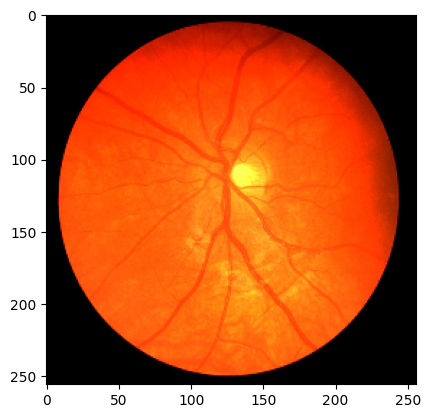

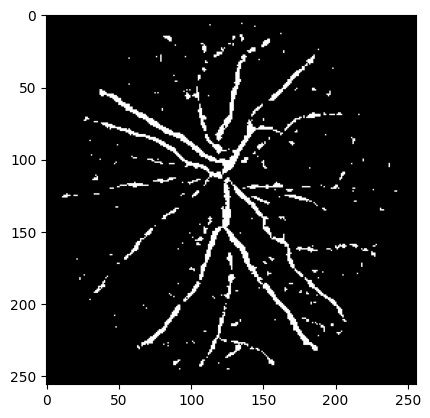

In [33]:
c = 0
with torch.no_grad():
    for i,m in test_loader:
        o =  model(i.cuda())[0]
        o = o.cpu().numpy()[0]
        o[o>=0.5]=1
        o[o<0.5]=0
        plt.imshow(torch.permute(i[0,0:3], (1,2,0)).cpu().numpy()[:,:,::-1])
        plt.show()
        plt.imshow(o, cmap="gray")
        plt.show()
        c+=1
        if c==1:
            break

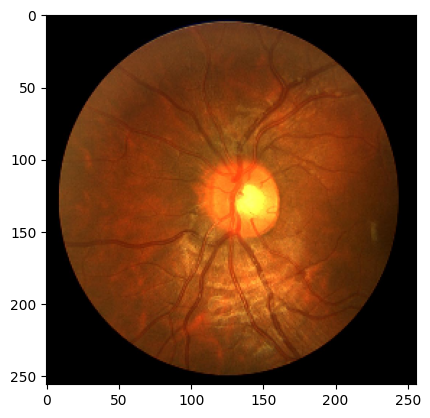

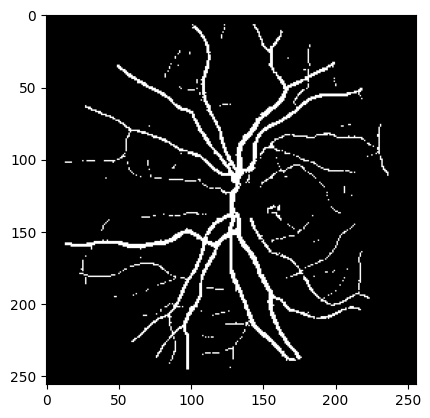

In [34]:
c = 0
with torch.no_grad():
    for i,m in train_loader:
        o =  model(i.cuda())[0]
        o = o.cpu().numpy()[0]
        o[o>=0.5]=1
        o[o<0.5]=0
        plt.imshow(torch.permute(i[0,0:3], (1,2,0)).cpu().numpy()[:,:,::-1])
        plt.show()
        plt.imshow(o, cmap="gray")
        plt.show()
        c+=1
        if c==1:
            break